# Detecting and splitting two-page openings

This notebook demonstrates `archival_structures.analysis.opening_detection` on the full
`NL-AsnDA_0114.11_1` inventory number (630 scans).

The key design point: deciding whether a scan is a two-page opening is **corpus-relative**.
An earlier version of this heuristic looked only at whether there's a detectable empty gap
between the two pages -- but dense handwriting frequently bridges that gutter with no visible
gap at all, even on genuine openings. What actually separates single pages from openings
cleanly in this inventory is scan width relative to the rest of the inventory (single pages are
digitised at roughly half the width). `compute_corpus_median_width` computes that reference
width once per inventory number, and `is_opening`/`get_opening_features` use it as the primary
signal -- checked against this exact inventory, where only the first and last scans are single
pages.

In [6]:
from pathlib import Path

import numpy as np
from PIL import Image, ImageDraw
import pagexml.parser as pagexml_parser

from archival_structures.image.image_base import make_selection
from archival_structures.model.image import Box
from archival_structures.analysis.opening_detection import (
    compute_corpus_median_width, get_opening_features, is_opening, split_scan, split_image,
)

INSTITUTE = 'NL-AsnDA'
ARCHIVE = 'NL-AsnDA_0114.11'
INVENTORY_NUM = 'NL-AsnDA_0114.11_1'
PAGEXML_DIR = Path('../../data/PageXML') / INSTITUTE / ARCHIVE / INVENTORY_NUM
IMAGE_DIR = Path('../../data/thumbs') / INSTITUTE / ARCHIVE / INVENTORY_NUM

assert PAGEXML_DIR.exists(), PAGEXML_DIR
assert IMAGE_DIR.exists(), IMAGE_DIR


def thumb_path_for(xml_path: Path) -> Path:
    return IMAGE_DIR / f"thumb-width_300-scan-{xml_path.stem}.jp2.png"

## Classify every scan in the inventory number

In [7]:
xml_paths = sorted(PAGEXML_DIR.glob('*.xml'))
scans = [pagexml_parser.parse_pagexml_file(str(xml_path)) for xml_path in xml_paths]
print(f"{len(scans)} scans loaded")

median_width = compute_corpus_median_width(scans)
print(f"corpus median width: {median_width}")

non_openings = [scan.id for scan in scans if not is_opening(scan, corpus_median_width=median_width)]
print(f"\n{len(non_openings)} scans classified as single pages (not openings):")
for scan_id in non_openings:
    print(f"  {scan_id}")

630 scans loaded
corpus median width: 4993.0

2 scans classified as single pages (not openings):
  NL-AsnDA_0114.11_1_0001.jpg
  NL-AsnDA_0114.11_1_0630.jpg


## Look at the features behind the decision

`width_ratio` (scan width / corpus median width) is the primary signal. `gap_width` is still
computed -- it's useful for locating the split point -- but notice it can be small or even zero
on a real opening (no clean visible gutter), which is exactly the case that broke the old,
gap-only heuristic.

In [8]:
import pandas as pd

rows = []
for scan in scans[:10]:
    features = get_opening_features(scan, corpus_median_width=median_width)
    rows.append({'scan_id': scan.id, 'width': scan.coords.w, 'width_ratio': round(features.width_ratio, 3),
                'gap_width': features.gap_width, 'is_opening': features.is_opening})
pd.DataFrame(rows)

,scan_id,width,width_ratio,gap_width,is_opening
0,NL-AsnDA_0114.11_1_0001.jpg,2600,0.521,0,False
1,NL-AsnDA_0114.11_1_0002.jpg,4904,0.982,140,True
2,NL-AsnDA_0114.11_1_0003.jpg,4937,0.989,35,True
3,NL-AsnDA_0114.11_1_0004.jpg,4937,0.989,90,True
4,NL-AsnDA_0114.11_1_0005.jpg,4937,0.989,560,True
5,NL-AsnDA_0114.11_1_0006.jpg,4937,0.989,2540,True
6,NL-AsnDA_0114.11_1_0007.jpg,4937,0.989,575,True
7,NL-AsnDA_0114.11_1_0008.jpg,4937,0.989,2575,True
8,NL-AsnDA_0114.11_1_0009.jpg,4937,0.989,40,True
9,NL-AsnDA_0114.11_1_0010.jpg,4937,0.989,55,True


## Visualise the split point on an opening

The red line marks `separation_point.x`, converted from scan space into thumbnail space with
`image_sel.scan_to_thumb` (the same `Transform` used throughout this package).

OpeningFeatures(separation_point=Point(x=2450, y=0), gap_width=140, width_ratio=0.9821750450630883, is_opening=True)


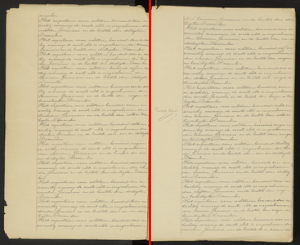

In [9]:
example_xml = xml_paths[1]  # _0002, a two-column opening
example_scan = scans[1]
thumb_path = thumb_path_for(example_xml)
image_sel = make_selection(example_scan.coords.w, example_scan.coords.h, str(thumb_path))
thumb_image = Image.open(thumb_path).convert('RGB')
features = get_opening_features(example_scan, corpus_median_width=median_width)
print(features)

thumb_sep_x = image_sel.scan_to_thumb.apply(Box(features.separation_point.x, 0, 0, 0)).x
annotated = thumb_image.copy()
ImageDraw.Draw(annotated).line([(thumb_sep_x, 0), (thumb_sep_x, thumb_image.height)], fill='red', width=2)
annotated

## Split the scan and the thumbnail

`split_scan` partitions the PageXML regions into a verso/recto pair (translating the recto's
coordinates so it starts at x=0); `split_image` does the same for a pixel array, here applied to
the thumbnail (after converting the separation point into thumbnail space, since `split_image`
expects the image and the separation point to be in the same coordinate space).

In [10]:
verso_scan, recto_scan = split_scan(example_scan, features.separation_point)
print(f"verso: {verso_scan.id}, regions {[r.id for r in verso_scan.text_regions]}, coords {verso_scan.coords.box}")
print(f"recto: {recto_scan.id}, regions {[r.id for r in recto_scan.text_regions]}, coords {recto_scan.coords.box}")

thumb_array = np.array(thumb_image)
sep_point_type = type(features.separation_point)
thumb_separation_point = sep_point_type(thumb_sep_x, features.separation_point.y)
verso_image, recto_image = split_image(thumb_array, thumb_separation_point)
print(f"verso image shape: {verso_image.shape}, recto image shape: {recto_image.shape}")

verso: NL-AsnDA_0114.11_1_0002.jpg-verso, regions ['r1'], coords {'x': 0, 'y': 0, 'w': 2450, 'h': 4009}
recto: NL-AsnDA_0114.11_1_0002.jpg-recto, regions ['r2', 'r3'], coords {'x': 0, 'y': 0, 'w': 2454, 'h': 4009}
verso image shape: (245, 150, 3), recto image shape: (245, 150, 3)


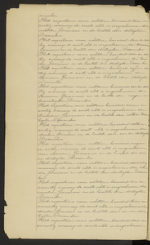

In [11]:
Image.fromarray(verso_image)

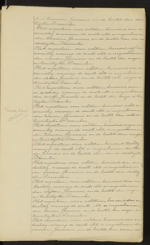

In [12]:
Image.fromarray(recto_image)

## A single page, for comparison

`_0001` has a much smaller `width_ratio` (around 0.52), so it's correctly classified as not an
opening regardless of `gap_width`.

OpeningFeatures(separation_point=Point(x=1365, y=2713.0), gap_width=0, width_ratio=0.5207290206288804, is_opening=False)


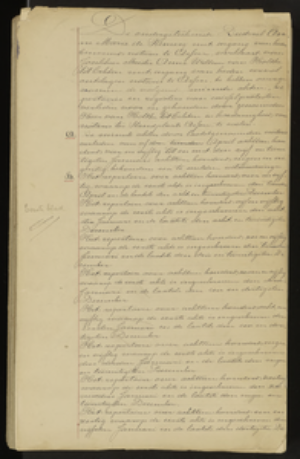

In [13]:
single_page_scan = scans[0]  # _0001
print(get_opening_features(single_page_scan, corpus_median_width=median_width))

single_thumb_path = thumb_path_for(xml_paths[0])
Image.open(single_thumb_path).convert('RGB')